# Abnormal crowd behavior classification with a 2D CNN

Dataset: [Roboflow – Abnormal Behavior Detection v1](https://universe.roboflow.com/abnormal-behavior-detection/abnormal-behavior-detection-5geje/dataset/1) (YOLOv8 export, CC BY 4.0).

The dataset is labeled for **object detection** (bounding boxes), so this notebook:
1. Converts box labels to **one label per image** (`normal` / `fall` / `fight`, or binary `normal` / `abnormal`).
2. Re-splits the data **by source video**, because Roboflow's original train/valid split interleaves consecutive frames from the same clips (which inflates validation scores).
3. Fine-tunes a pretrained ResNet-18 (or trains a small CNN from scratch) and evaluates on a held-out test split.

> **Kaggle setup:** Settings → Accelerator → **GPU T4 / P100**. Internet is only needed for the pretrained weights.

In [12]:
import os, re, glob, random, collections
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms as T

# ---------------- config ----------------
DATA_ROOT  = "/kaggle/input/datasets/vallabhgopu/abnormal-behavior-detection-v1i-yolov8"
TASK       = "3class"     # "3class" -> normal/fall/fight ; "binary" -> normal/abnormal
MODEL      = "resnet18"   # "resnet18" (pretrained, recommended) or "custom" (small CNN from scratch)
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 15           # bump to ~40 for MODEL="custom"
LR         = 3e-4 if MODEL == "resnet18" else 1e-3
CHUNK      = 100          # frames per group for the long numbered sequences (see split section)
SEED       = 42
NUM_WORKERS = 2

def seed_everything(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## 1. Load YOLO labels

`data.yaml` lists 6 classes: `['0', '1', '2', 'fall', 'fight', 'normal']`. The numbered classes appear to be a second
annotation scheme for the same three behaviors: `0`+`2` co-occur exactly like `normal`+`fight`, and `1` only appears in
the fall-video sources alongside `fall`. So we merge `0→normal`, `1→fall`, `2→fight` (verify visually in section 2).

In [13]:
# locate data.yaml wherever Kaggle put it (handles an extra nesting level from zip uploads)
yaml_path = glob.glob(os.path.join(DATA_ROOT, "**", "data.yaml"), recursive=True)[0]
root = os.path.dirname(yaml_path)
names = yaml.safe_load(open(yaml_path))["names"]
print("root:", root); print("raw classes:", names)

MERGE = {"0": "normal", "1": "fall", "2": "fight", "normal": "normal", "fall": "fall", "fight": "fight"}

def group_of(fname):
    """Source-video id from a Roboflow filename like 'seq12-frame_034_png.rf.<hash>.jpg'."""
    stem = re.sub(r"_(png|jpg|jpeg)$", "", fname.split(".rf.")[0])
    prefix, num = re.match(r"^(.*?)(\d+)$", stem).groups()
    if prefix in ("", "p"):            # long numbered sequences with no video id -> contiguous chunks
        return f"{prefix or 'num'}_{int(num) // CHUNK}"
    return prefix                      # e.g. 'seq12-frame_', 'fall-07-cam0-rgb-', 'fi036-frame_'

rows = []
for split in ("train", "valid", "test"):
    for img in sorted(glob.glob(os.path.join(root, split, "images", "*"))):
        lbl = os.path.join(root, split, "labels", os.path.splitext(os.path.basename(img))[0] + ".txt")
        raw = [names[int(l.split()[0])] for l in open(lbl) if l.strip()] if os.path.exists(lbl) else []
        rows.append({"path": img, "orig_split": split, "raw": raw,
                     "classes": sorted({MERGE[c] for c in raw}), "group": group_of(os.path.basename(img))})
df = pd.DataFrame(rows)
print(len(df), "images,", df.group.nunique(), "groups")
print(df.orig_split.value_counts().to_dict())

root: /kaggle/input/datasets/vallabhgopu/abnormal-behavior-detection-v1i-yolov8
raw classes: ['0', '1', '2', 'fall', 'fight', 'normal']
3709 images, 218 groups
{'train': 1862, 'valid': 1847}


### 1b. Data validation & cleaning
- **Corrupt images:** every file must open and decode.
- **Annotations:** each label line must be `class cx cy w h`, with a valid class id and a box inside the image (normalized coords in [0, 1]). Empty label files are counted here and dropped in the next cell.
- **Exact duplicates:** byte-identical images (Roboflow exported some frames twice) are removed, keeping one copy.
- **Near-duplicates:** consecutive video frames are *reported*, not removed. They are handled by the group-aware split in section 3, which keeps every frame of a video in the same split.

In [14]:
import hashlib

def label_path(img):
    return os.path.join(os.path.dirname(os.path.dirname(img)), "labels", os.path.splitext(os.path.basename(img))[0] + ".txt")

def dhash(im, size=16):   # 256-bit difference hash for near-duplicate detection
    a = np.asarray(im.convert("L").resize((size + 1, size)), dtype=np.int16)
    return (a[:, 1:] > a[:, :-1]).flatten().tobytes()

report = collections.Counter()
keep, md5_seen, dh = [], {}, collections.defaultdict(list)
for i, r in df.iterrows():
    # 1) corrupt image check
    try:
        with Image.open(r.path) as im: im.verify()
        with Image.open(r.path) as im: h_near = dhash(im)
    except Exception as e:
        report["corrupt image"] += 1; print("corrupt:", r.path, e); continue

    # 2) annotation validation
    lines = [l.split() for l in open(label_path(r.path)) if l.strip()] if os.path.exists(label_path(r.path)) else []
    ok = True
    for l in lines:
        report["boxes checked"] += 1
        if len(l) != 5 or not l[0].isdigit() or int(l[0]) >= len(names):
            report["malformed label line"] += 1; ok = False; continue
        cx, cy, w, h = map(float, l[1:])
        if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 < w <= 1 and 0 < h <= 1
                and cx - w/2 >= -1e-3 and cx + w/2 <= 1 + 1e-3 and cy - h/2 >= -1e-3 and cy + h/2 <= 1 + 1e-3):
            report["out-of-range box"] += 1; ok = False
    if not lines: report["empty label file"] += 1
    if not ok: continue

    # 3) exact duplicate removal
    md5 = hashlib.md5(open(r.path, "rb").read()).hexdigest()
    if md5 in md5_seen:
        report["exact duplicate removed"] += 1; continue
    md5_seen[md5] = i
    dh[h_near].append(r.group)
    keep.append(i)

n_before = len(df)
df = df.loc[keep].reset_index(drop=True)

# 4) near-duplicate report
near = [g for g in dh.values() if len(g) > 1]
report["near-duplicate clusters"] = len(near)
report["near-dup clusters spanning >1 video group"] = sum(len(set(g)) > 1 for g in near)

for k in ["corrupt image", "boxes checked", "malformed label line", "out-of-range box", "empty label file",
          "exact duplicate removed", "near-duplicate clusters", "near-dup clusters spanning >1 video group"]:
    print(f"{k:45s} {report[k]}")
print(f"\nimages: {n_before} -> {len(df)}")

corrupt image                                 0
boxes checked                                 7357
malformed label line                          0
out-of-range box                              0
empty label file                              1
exact duplicate removed                       109
near-duplicate clusters                       63
near-dup clusters spanning >1 video group     15

images: 3709 -> 3600


In [15]:
# image-level label: an abnormal event anywhere in the frame makes the frame abnormal
def image_label(classes):
    if not classes:            return None   # unlabeled -> drop
    if "fight" in classes:     return "fight"
    if "fall" in classes:      return "fall"
    return "normal"

df["label"] = df.classes.apply(image_label)
df = df.dropna(subset=["label"]).reset_index(drop=True)
if TASK == "binary":
    df["label"] = df.label.map(lambda c: "normal" if c == "normal" else "abnormal")

CLASSES = sorted(df.label.unique())
cls2idx = {c: i for i, c in enumerate(CLASSES)}
df["y"] = df.label.map(cls2idx)
print(CLASSES)
print(df.label.value_counts())
print("\nraw-class combinations:"); print(df.raw.apply(lambda r: tuple(sorted(set(r)))).value_counts().head(10))

['fall', 'fight', 'normal']
label
normal    1200
fall      1200
fight     1199
Name: count, dtype: int64

raw-class combinations:
raw
(normal,)          600
(fall,)            600
(1,)               600
(0,)               600
(fight, normal)    329
(2,)               300
(0, 2)             300
(fight,)           270
Name: count, dtype: int64


## 2. Sanity check: what do the numbered classes look like?
Each row shows images whose boxes are *only* that raw class. If `0` looks like `normal`, `1` like `fall`, `2` like `fight`, the merge is right.

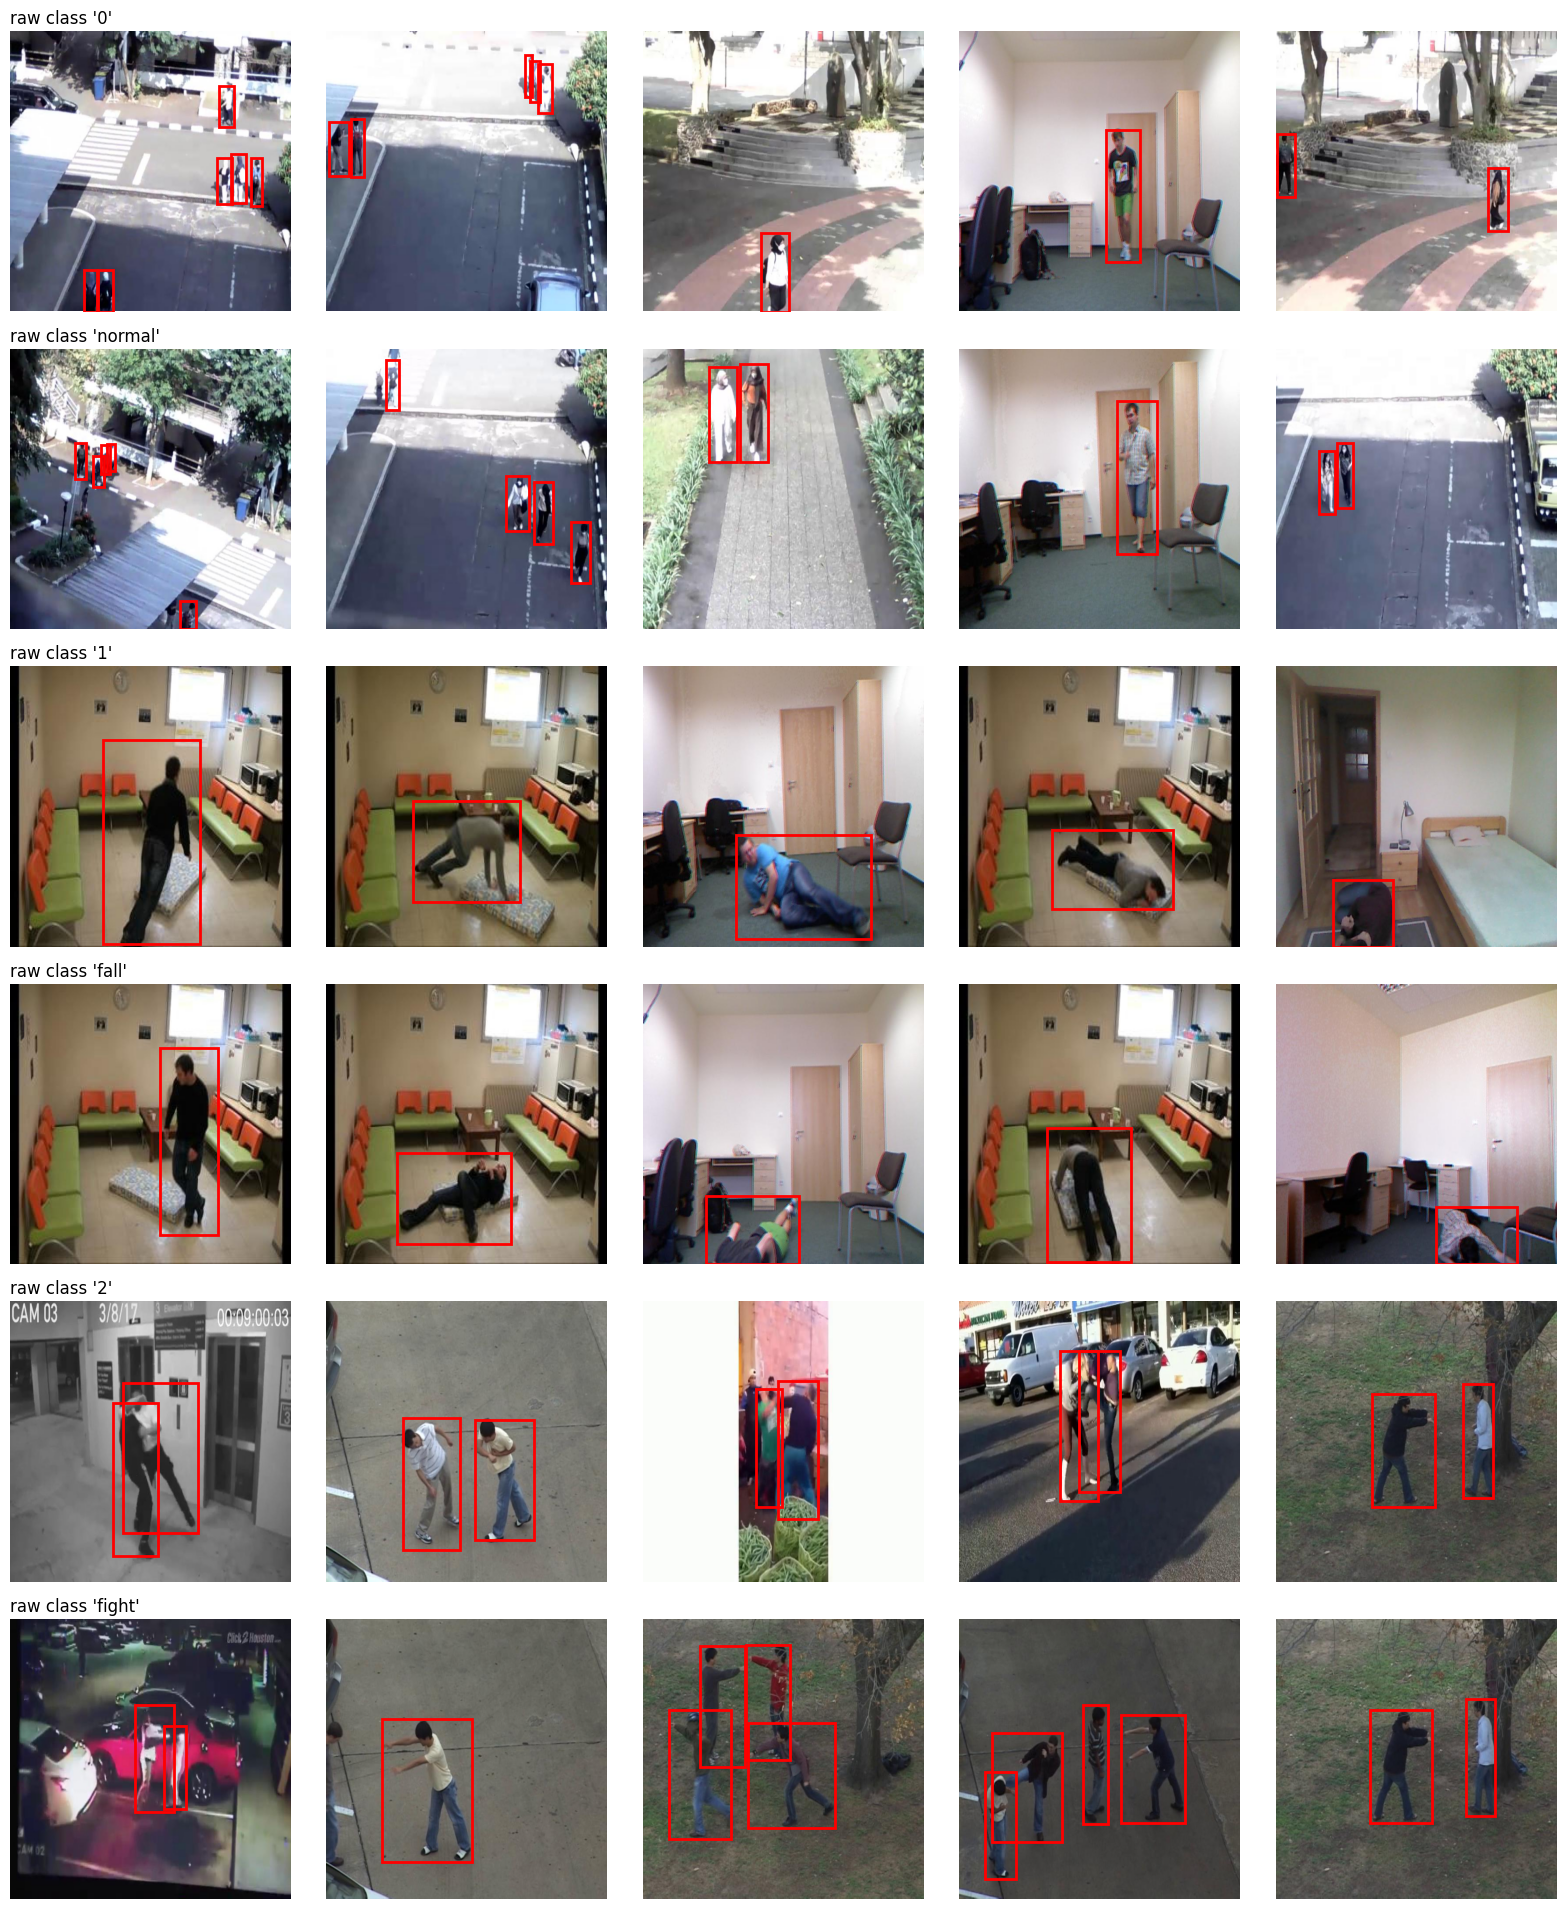

In [16]:
def show_raw(raw_cls, n=5, ax_row=None):
    sub = df[df.raw.apply(lambda r: set(r) == {raw_cls})]   # images with only this raw class
    for ax, (_, r) in zip(ax_row, sub.sample(min(n, len(sub)), random_state=SEED).iterrows()):
        im = Image.open(r.path); W, H = im.size
        ax.imshow(im); ax.axis("off")
        lbl = os.path.join(os.path.dirname(os.path.dirname(r.path)), "labels",
                           os.path.splitext(os.path.basename(r.path))[0] + ".txt")
        for l in open(lbl):
            c, cx, cy, w, h = l.split(); cx, cy, w, h = map(float, (cx, cy, w, h))
            ax.add_patch(plt.Rectangle(((cx - w/2) * W, (cy - h/2) * H), w * W, h * H, fill=False,
                                       color="red" if names[int(c)] == raw_cls else "lime", lw=2))
    ax_row[0].set_title(f"raw class '{raw_cls}'", loc="left")

raw_to_show = ["0", "normal", "1", "fall", "2", "fight"]
fig, axes = plt.subplots(len(raw_to_show), 5, figsize=(16, 3.2 * len(raw_to_show)))
for row, c in zip(axes, raw_to_show): show_raw(c, ax_row=row)
plt.tight_layout(); plt.show()

## 3. Group-aware train / val / test split

Frames from one video are near-duplicates, so a frame-level random split leaks. We group by source video
(`seq12-frame_*`, `fall-07-cam0-rgb-*`, …). The two long numbered sequences (`000123.png`, `p1007.png`) have no video id,
so they are cut into contiguous blocks of `CHUNK` frames. Split ≈ 60 / 20 / 20 with `StratifiedGroupKFold`.

In [17]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
trval_idx, test_idx = next(sgkf.split(df, df.y, df.group))
trval = df.iloc[trval_idx]
sgkf2 = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED)
tr_i, va_i = next(sgkf2.split(trval, trval.y, trval.group))

df["split"] = "test"
df.loc[trval.index[tr_i], "split"] = "train"
df.loc[trval.index[va_i], "split"] = "val"

assert not (set(df[df.split == "train"].group) & set(df[df.split != "train"].group)), "group leak!"
print(pd.crosstab(df.label, df.split, margins=True))

split   test  train  val   All
label                         
fall     288    668  244  1200
fight    141    725  333  1199
normal   355    681  164  1200
All      784   2074  741  3599


## 4. Data pipeline

In [18]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.3, 0.3, 0.3, 0.05),
    T.ToTensor(), T.Normalize(MEAN, STD),
])
eval_tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN, STD)])

class FrameDS(Dataset):
    def __init__(self, frame, tf): self.p, self.y, self.tf = frame.path.tolist(), frame.y.tolist(), tf
    def __len__(self): return len(self.p)
    def __getitem__(self, i): return self.tf(Image.open(self.p[i]).convert("RGB")), self.y[i]

loaders = {
    s: DataLoader(FrameDS(df[df.split == s], train_tf if s == "train" else eval_tf),
                  batch_size=BATCH_SIZE, shuffle=(s == "train"), num_workers=NUM_WORKERS, pin_memory=True)
    for s in ("train", "val", "test")
}

# class weights for the (mild) imbalance
counts = df[df.split == "train"].y.value_counts().sort_index().values
class_w = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float32, device=device)
print("class weights:", dict(zip(CLASSES, class_w.cpu().numpy().round(2))))

class weights: {'fall': np.float32(1.03), 'fight': np.float32(0.95), 'normal': np.float32(1.02)}


## 5. Model
`resnet18`: ImageNet-pretrained, final layer replaced. `custom`: a plain 4-block 2D CNN trained from scratch (useful as a baseline for the report).

In [19]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        def block(i, o): return nn.Sequential(
            nn.Conv2d(i, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
            nn.Conv2d(o, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
            nn.MaxPool2d(2))
        self.features = nn.Sequential(block(3, 32), block(32, 64), block(64, 128), block(128, 256))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, n_classes))
    def forward(self, x): return self.head(self.features(x))

def build_model():
    if MODEL == "resnet18":
        m = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
        m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.fc.in_features, len(CLASSES)))
        return m
    return SmallCNN(len(CLASSES))

model = build_model().to(device)
print(f"{MODEL}: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M params")

resnet18: 11.18M params


## 6. Train

In [20]:
criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR, total_steps=EPOCHS * len(loaders["train"]))
scaler = torch.amp.GradScaler(enabled=(device == "cuda"))

@torch.no_grad()
def predict(loader):
    model.eval(); ys, ps = [], []
    for x, y in loader:
        with torch.autocast(device_type=device, enabled=(device == "cuda")):
            ps.append(model(x.to(device, non_blocking=True)).argmax(1).cpu())
        ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()

hist, best_f1 = [], -1
for epoch in range(1, EPOCHS + 1):
    model.train(); tot, correct, loss_sum = 0, 0, 0.0
    for x, y in loaders["train"]:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device, enabled=(device == "cuda")):
            out = model(x); loss = criterion(out, y)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update(); scheduler.step()
        loss_sum += loss.item() * len(y); correct += (out.argmax(1) == y).sum().item(); tot += len(y)

    yv, pv = predict(loaders["val"])
    val_f1, val_acc = f1_score(yv, pv, average="macro"), (yv == pv).mean()
    hist.append(dict(epoch=epoch, train_loss=loss_sum / tot, train_acc=correct / tot, val_acc=val_acc, val_f1=val_f1))
    flag = ""
    if val_f1 > best_f1:
        best_f1 = val_f1; torch.save(model.state_dict(), "best.pt"); flag = "  *saved*"
    print(f"ep {epoch:2d} | loss {loss_sum/tot:.3f} acc {correct/tot:.3f} | val acc {val_acc:.3f} macro-F1 {val_f1:.3f}{flag}")

ep  1 | loss 0.519 acc 0.844 | val acc 0.964 macro-F1 0.959  *saved*
ep  2 | loss 0.231 acc 0.982 | val acc 0.964 macro-F1 0.959  *saved*
ep  3 | loss 0.220 acc 0.986 | val acc 0.965 macro-F1 0.960  *saved*
ep  4 | loss 0.223 acc 0.986 | val acc 0.965 macro-F1 0.961  *saved*
ep  5 | loss 0.216 acc 0.988 | val acc 0.974 macro-F1 0.972  *saved*
ep  6 | loss 0.200 acc 0.994 | val acc 0.951 macro-F1 0.948
ep  7 | loss 0.205 acc 0.992 | val acc 0.970 macro-F1 0.966
ep  8 | loss 0.200 acc 0.991 | val acc 0.970 macro-F1 0.966
ep  9 | loss 0.194 acc 0.994 | val acc 0.991 macro-F1 0.988  *saved*
ep 10 | loss 0.188 acc 0.996 | val acc 0.970 macro-F1 0.967
ep 11 | loss 0.193 acc 0.994 | val acc 0.970 macro-F1 0.967
ep 12 | loss 0.186 acc 0.996 | val acc 0.972 macro-F1 0.968
ep 13 | loss 0.186 acc 0.997 | val acc 0.972 macro-F1 0.968
ep 14 | loss 0.183 acc 0.999 | val acc 0.972 macro-F1 0.969
ep 15 | loss 0.183 acc 1.000 | val acc 0.970 macro-F1 0.967


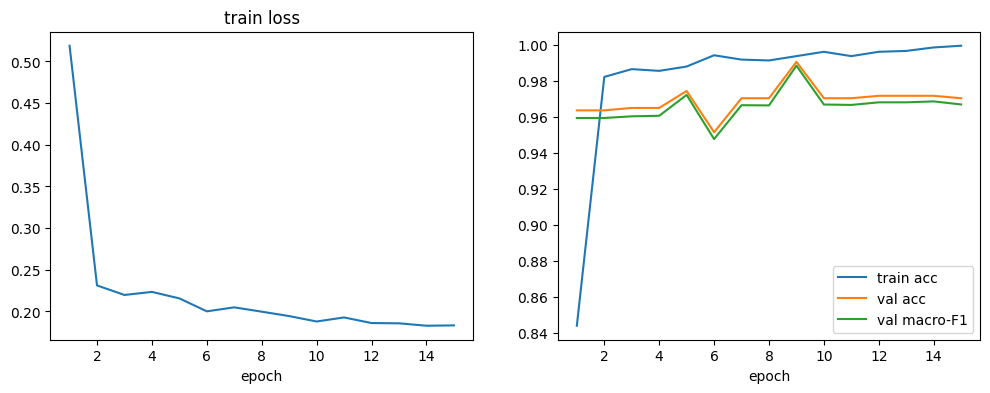

In [21]:
h = pd.DataFrame(hist)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h.epoch, h.train_loss); ax[0].set_title("train loss"); ax[0].set_xlabel("epoch")
ax[1].plot(h.epoch, h.train_acc, label="train acc"); ax[1].plot(h.epoch, h.val_acc, label="val acc")
ax[1].plot(h.epoch, h.val_f1, label="val macro-F1"); ax[1].legend(); ax[1].set_xlabel("epoch")
plt.show()

## 7. Test-set evaluation (best checkpoint)

              precision    recall  f1-score   support

        fall      0.980     1.000     0.990       288
       fight      1.000     1.000     1.000       141
      normal      1.000     0.983     0.991       355

    accuracy                          0.992       784
   macro avg      0.993     0.994     0.994       784
weighted avg      0.993     0.992     0.992       784



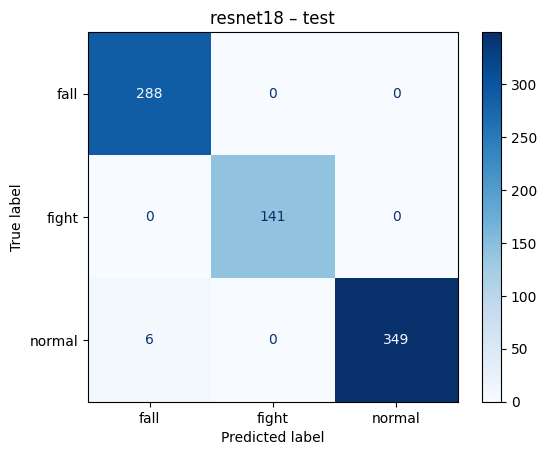

In [22]:
model.load_state_dict(torch.load("best.pt", map_location=device))
yt, pt = predict(loaders["test"])
print(classification_report(yt, pt, target_names=CLASSES, digits=3))
ConfusionMatrixDisplay(confusion_matrix(yt, pt), display_labels=CLASSES).plot(cmap="Blues")
plt.title(f"{MODEL} – test"); plt.show()

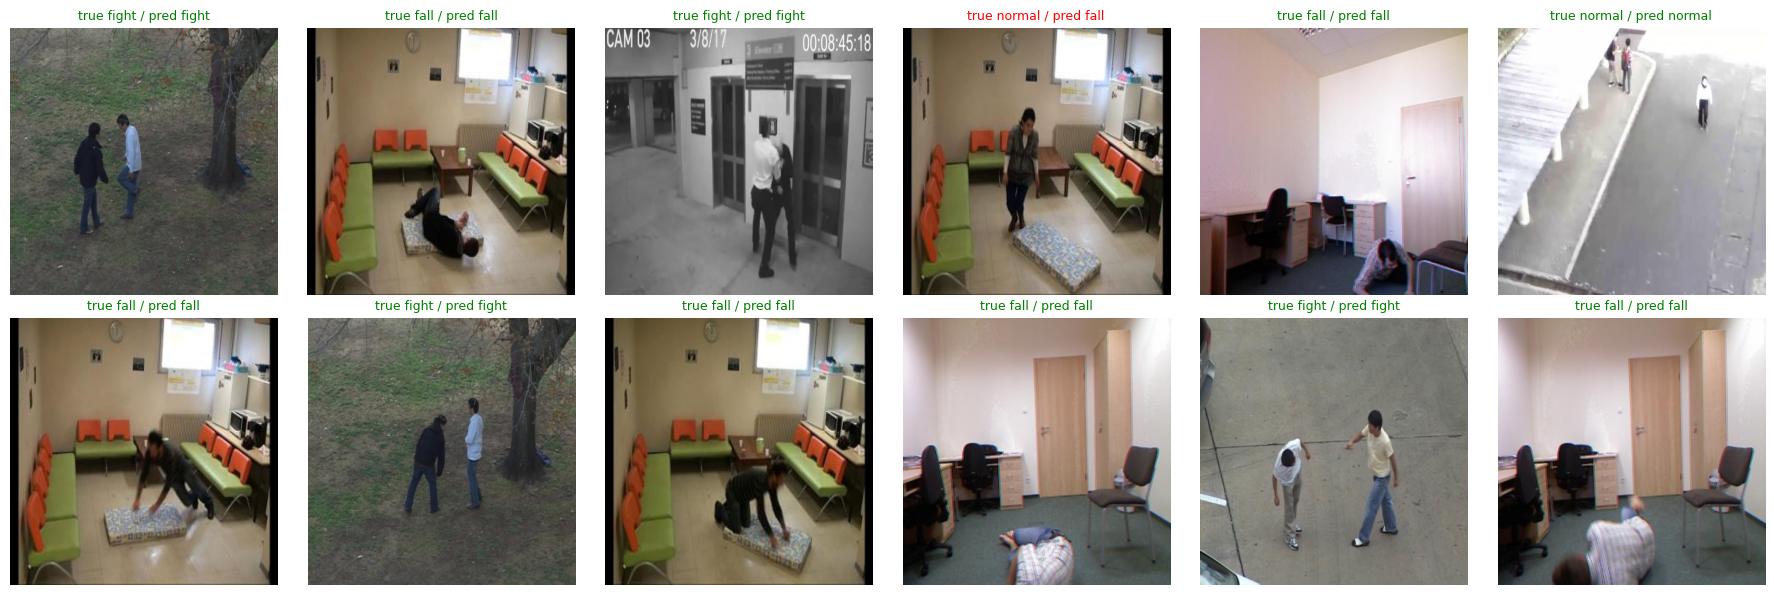

In [23]:
# a few test predictions (red title = wrong)
test_df = df[df.split == "test"].reset_index(drop=True)
idx = np.random.default_rng(SEED).choice(len(test_df), 12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for ax, i in zip(axes.flat, idx):
    ax.imshow(Image.open(test_df.path[i])); ax.axis("off")
    ax.set_title(f"true {CLASSES[yt[i]]} / pred {CLASSES[pt[i]]}", color="green" if yt[i] == pt[i] else "red", fontsize=9)
plt.tight_layout(); plt.show()